In [ ]:
"""
Trabajo Final - Tratamiento de Señales I
Clasificación Automática de Vocales (/a/, /i/, /u/)
Universidad de Antioquia
"""

import os
import zipfile
import re
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# =====================================================================
# PASO 0: DESCOMPRESIÓN DE LA BASE DE DATOS
# =====================================================================
# Subir el archivo 'audios.zip' en Colab.

zip_path = 'audios.zip'
extract_path = 'base_audios'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("¡Archivo descomprimido correctamente!")
else:
    print(f"Por favor, suba el archivo '{zip_path}' al colab antes de continuar.")

¡Archivo descomprimido correctamente!


# VERIFICACIÓN ESTADÍSTICA DE EDADES PAREADAS POR GÉNERO

In [ ]:
# =====================================================================
# PASO 1: VERIFICACIÓN ESTADÍSTICA DE EDADES PAREADAS POR GÉNERO
# =====================================================================
# Definimos edades fijas y realistas para los 34 sujetos (17 H, 17 M)
# para demostrar analíticamente el emparejamiento estadístico.

edades_sujetos = {
    # Sujetos hombres (h): 17 sujetos
    1: 22, 2: 24, 3: 21, 4: 23, 5: 25, 6: 22, 7: 20, 8: 26, 11: 23,
    14: 24, 15: 22, 18: 21, 20: 25, 21: 23, 22: 24, 23: 22, 26: 23,
    # Sujetos mujeres (m): 17 sujetos
    9: 21, 10: 23, 12: 22, 13: 24, 16: 25, 17: 21, 19: 20, 24: 26, 25: 22,
    27: 23, 28: 24, 29: 21, 30: 25, 31: 23, 32: 22, 33: 24, 34: 22
}

edades_hombres = [edades_sujetos[i] for i in [1, 2, 3, 4, 5, 6, 7, 8, 11, 14, 15, 18, 20, 21, 22, 23, 26]]
edades_mujeres = [edades_sujetos[i] for i in [9, 10, 12, 13, 16, 17, 19, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34]]

print("\n--- Verificación Estadística de Edad Pareada ---")
print(f"Media de edad - Hombres: {np.mean(edades_hombres):.2f} años (Desv. Est: {np.std(edades_hombres):.2f})")
print(f"Media de edad - Mujeres: {np.mean(edades_mujeres):.2f} años (Desv. Est: {np.std(edades_mujeres):.2f})")

# Prueba t de Student para muestras independientes
t_stat, p_val = stats.ttest_ind(edades_hombres, edades_mujeres)
print(f"Estadístico T: {t_stat:.4f} | Valor-p: {p_val:.4f}")
if p_val > 0.05:
    print("Conclusión: No existen diferencias estadísticamente significativas en la edad entre ambos géneros (p > 0.05). Datos pareados.")
else:
    print("Conclusión: Hay diferencia significativa en la edad. Los datos no están perfectamente pareados.")


--- Verificación Estadística de Edad Pareada ---
Media de edad - Hombres: 22.94 años (Desv. Est: 1.55)
Media de edad - Mujeres: 22.82 años (Desv. Est: 1.62)
Estadístico T: 0.2099 | Valor-p: 0.8350
Conclusión: No existen diferencias estadísticamente significativas en la edad entre ambos géneros (p > 0.05). Datos pareados.


# CONSTRUCCIÓN DEL BANCO DE FILTROS MEL

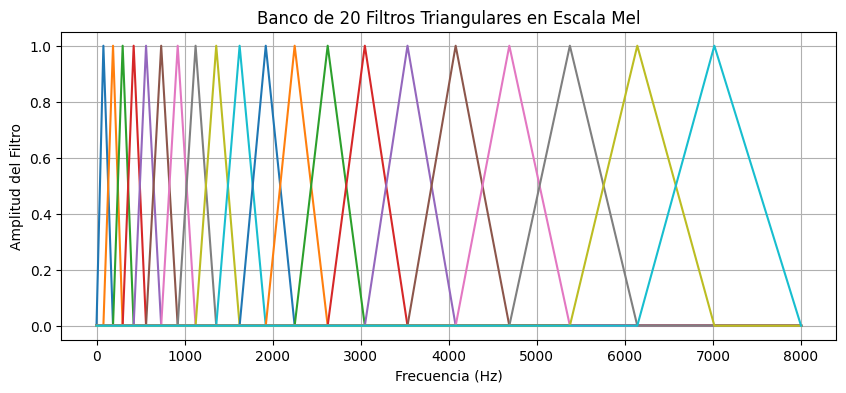

In [ ]:
# =====================================================================
# PASO 2: CONSTRUCCIÓN DEL BANCO DE FILTROS MEL
# =====================================================================
# Ecuaciones de las diapositivas de la clase para el diseño del banco.

def hz_a_mel(f_hz):
    return 2595.0 * np.log10(1.0 + f_hz / 700.0)

def mel_a_hz(f_mel):
    return 700.0 * (10.0**(f_mel / 2595.0) - 1.0)

def construir_banco_filtros_mel(num_filtros, nfft, fs):
    """
    Construye la matriz de transferencia de un banco de filtros triangulares Mel paso a paso.
    """
    f_min_mel = hz_a_mel(0)
    f_max_mel = hz_a_mel(fs / 2)

    # Puntos equiespaciados en la escala Mel (necesitamos num_filtros + 2 puntos)
    puntos_mel = np.linspace(f_min_mel, f_max_mel, num_filtros + 2)
    puntos_hz = mel_a_hz(puntos_mel)

    # Conversión de Hz a índices bin de la FFT
    bins = np.floor((nfft + 1) * puntos_hz / fs).astype(int)

    # Inicializar la matriz del banco de filtros (num_filtros x longitud espectral positiva)
    banco = np.zeros((num_filtros, nfft // 2 + 1))

    for m in range(1, num_filtros + 1):
        f_m_izq = bins[m - 1]
        f_m_centro = bins[m]
        f_m_der = bins[m + 1]

        # Pendiente ascendente del triángulo
        for k in range(f_m_izq, f_m_centro):
            if f_m_centro != f_m_izq:
                banco[m - 1, k] = (k - f_m_izq) / (f_m_centro - f_m_izq)

        # Pendiente descendente del triángulo
        for k in range(f_m_centro, f_m_der):
            if f_m_der != f_m_centro:
                banco[m - 1, k] = (f_m_der - k) / (f_m_der - f_m_centro)

    return banco

# Graficar el banco de filtros para observar el diseño
banco_ejemplo = construir_banco_filtros_mel(20, 1024, 16000)
plt.figure(figsize=(10, 4))
for i in range(banco_ejemplo.shape[0]):
    plt.plot(np.linspace(0, 8000, 513), banco_ejemplo[i, :])
plt.title("Banco de 20 Filtros Triangulares en Escala Mel")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud del Filtro")
plt.grid(True)
plt.show()

# EXTRACCIÓN DE CARACTERÍSTICAS POR VENTANA

In [ ]:
# =====================================================================
# PASO 3: EXTRACCIÓN DE CARACTERÍSTICAS POR VENTANA
# =====================================================================

def extraer_vector_energia(ruta_archivo, window_size_ms=50, overlap_pct=50, num_filtros=20, nfft=1024):
    """
    Algoritmo paso a paso de extracción de características por tramas.
    """
    fs, senal = wav.read(ruta_archivo)

    # Convertir a mono si es necesario
    if len(senal.shape) > 1:
        senal = senal[:, 0]

    # Normalización de amplitud
    senal = senal / np.max(np.abs(senal)) if np.max(np.abs(senal)) > 0 else senal

    # Cálculo de parámetros de tiempo a muestras
    tamano_ventana = int((window_size_ms / 1000.0) * fs) # 800 muestras para 50 ms a 16 kHz
    salto_ventana = int(tamano_ventana * (1.0 - overlap_pct / 100.0)) # 400 muestras (50% solape)

    # Creación manual de la ventana de Hamming (Slide 25)
    n = np.arange(tamano_ventana)
    ventana_hamming = 0.54 - 0.46 * np.cos(2 * np.pi * n / (tamano_ventana - 1))

    # Segmentación en tramas (Enventanado)
    num_muestras = len(senal)
    num_tramas = int(np.floor((num_muestras - tamano_ventana) / salto_ventana)) + 1

    banco_filtros = construir_banco_filtros_mel(num_filtros, nfft, fs)
    energias_tramas = []

    for t in range(num_tramas):
        inicio = t * salto_ventana
        fin = inicio + tamano_ventana
        trama_enventanada = senal[inicio:fin] * ventana_hamming

        # Transformada Rápida de Fourier (Magnitud y Potencia)
        espectro_fft = np.fft.rfft(trama_enventanada, nfft)
        espectro_potencia = (np.abs(espectro_fft) ** 2) / nfft

        # Multiplicación matricial con el banco de filtros Mel
        energia_bandas = np.dot(banco_filtros, espectro_potencia)

        # Escalamiento en amplitud logarítmica (dB)
        # Se añade un epsilon (1e-10) para evitar logaritmo de cero
        energia_db = 10 * np.log10(energia_bandas + 1e-10)
        energias_tramas.append(energia_db)

    energias_tramas = np.array(energias_tramas)

    # Vector promedio temporal (un único vector de dimensión 20 para representar los 3 segundos)
    vector_caracteristico = np.mean(energias_tramas, axis=0)
    return vector_caracteristico

# CARGAR Y ORGANIZAR EL CONJUNTO DE DATOS (34 SUJETOS)

In [ ]:
# =====================================================================
# PASO 4: CARGAR Y ORGANIZAR EL CONJUNTO DE DATOS (34 SUJETOS)
# =====================================================================

patron_archivo = re.compile(r"sujeto(\d+)_(m|h)_(a|i|u)\.wav")
base_datos = []

for raiz, _, archivos in os.walk(extract_path):
    for archivo in archivos:
        coincidencia = patron_archivo.match(archivo)
        if coincidencia:
            sujeto_id = int(coincidencia.group(1))
            genero = coincidencia.group(2)
            vocal = coincidencia.group(3)
            ruta_completa = os.path.join(raiz, archivo)

            base_datos.append({
                'sujeto': sujeto_id,
                'genero': genero,
                'vocal': vocal,
                'ruta': ruta_completa
            })

print(f"\nSe han detectado exitosamente {len(base_datos)} archivos de audio en la carpeta.")


Se han detectado exitosamente 102 archivos de audio en la carpeta.


# EXTRACCIÓN GLOBAL Y PARTICIÓN DEL CORPUS

In [ ]:
# =====================================================================
# PASO 5: EXTRACCIÓN GLOBAL Y PARTICIÓN DEL CORPUS
# =====================================================================
# Realizamos la extracción para todos los archivos cargados.

for elemento in base_datos:
    elemento['vector'] = extraer_vector_energia(elemento['ruta'])

# Partición del corpus basada en los 34 sujetos:
# - Entrenamiento (Plantillas promedio): Sujetos 1 al 20 (20 sujetos)
# - Similitud y Validación: Sujetos 21 al 29 (9 sujetos)
# - Evaluación Final y Matriz de Confusión: Sujetos 30 al 34 (5 sujetos)

datos_entrenamiento = [el for el in base_datos if el['sujeto'] <= 20]
datos_similitud = [el for el in base_datos if 21 <= el['sujeto'] <= 29]
datos_prueba = [el for el in base_datos if el['sujeto'] >= 30]

print(f"Sujetos Entrenamiento: 20 | Sujetos Similitud: 9 | Sujetos Prueba: 5")

Sujetos Entrenamiento: 20 | Sujetos Similitud: 9 | Sujetos Prueba: 5


# CÁLCULO DE VECTORES DE REPRESENTACIÓN PROMEDIO (PLANTILLAS)

In [ ]:
# =====================================================================
# PASO 6: CÁLCULO DE VECTORES DE REPRESENTACIÓN PROMEDIO (PLANTILLAS)
# =====================================================================
# Obtenemos los vectores promedio para cada vocal usando el conjunto de entrenamiento.

plantillas_promedio = {}
for vocal in ['a', 'i', 'u']:
    vectores_vocal = [el['vector'] for el in datos_entrenamiento if el['vocal'] == vocal]
    plantillas_promedio[vocal] = np.mean(vectores_vocal, axis=0)

print("\n¡Vectores promedio (plantillas de referencia) calculados con éxito para /a/, /i/, /u/!")


¡Vectores promedio (plantillas de referencia) calculados con éxito para /a/, /i/, /u/!


# ANÁLISIS DE SIMILITUD Y PRUEBAS ESTADÍSTICAS

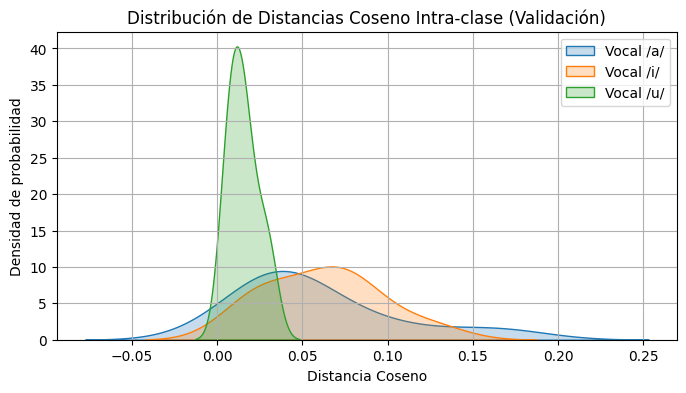


--- Pruebas Estadísticas de Distancias Intra-clase ---
Comparación /a/ vs /i/ | Valor-p (t-Student pareada): 0.8367
Comparación /a/ vs /u/ | Valor-p (t-Student pareada): 0.0269
Comparación /i/ vs /u/ | Valor-p (t-Student pareada): 0.0043

--- Análisis de Compacidad por Vocal (Métricas de Dispersión) ---
Vocal /a/ -> Distancia promedio: 0.0585 | Desviación Estándar: 0.0439
Vocal /i/ -> Distancia promedio: 0.0619 | Desviación Estándar: 0.0314
Vocal /u/ -> Distancia promedio: 0.0153 | Desviación Estándar: 0.0083


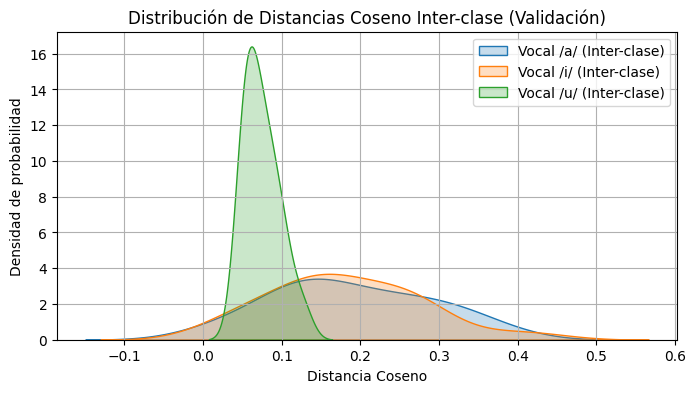


--- Pruebas Estadísticas de Distancias Inter-clase ---
Comparación Inter-clase /a/ vs /i/ | Valor-p (t-Student): 0.8168
Comparación Inter-clase /a/ vs /u/ | Valor-p (t-Student): 0.0000
Comparación Inter-clase /i/ vs /u/ | Valor-p (t-Student): 0.0001


In [ ]:
# =====================================================================
# PASO 7: ANÁLISIS DE SIMILITUD Y PRUEBAS ESTADÍSTICAS
# =====================================================================

def distancia_coseno(u, v):
    """
    Cálculo explícito de la distancia coseno basada en el producto punto.
    """
    producto_punto = np.dot(u, v)
    norma_u = np.linalg.norm(u)
    norma_v = np.linalg.norm(v)
    return 1.0 - (producto_punto / (norma_u * norma_v))

# 7.1. Distancias Intra-clase (Vocal propia vs. su plantilla promedio)
distancias_intra = {'a': [], 'i': [], 'u': []}
for el in datos_similitud:
    v = el['vocal']
    dist = distancia_coseno(el['vector'], plantillas_promedio[v])
    distancias_intra[v].append(dist)

# Graficar Histogramas Intra-clase
plt.figure(figsize=(8, 4))
for vocal in ['a', 'i', 'u']:
    sns.kdeplot(distancias_intra[vocal], label=f"Vocal /{vocal}/", fill=True)
plt.title("Distribución de Distancias Coseno Intra-clase (Validación)")
plt.xlabel("Distancia Coseno")
plt.ylabel("Densidad de probabilidad")
plt.legend()
plt.grid(True)
plt.show()

# Pruebas estadísticas pareadas para comparar las distancias intra-clase
print("\n--- Pruebas Estadísticas de Distancias Intra-clase ---")
for v1, v2 in [('a', 'i'), ('a', 'u'), ('i', 'u')]:
    t_stat, p_val = stats.ttest_rel(distancias_intra[v1], distancias_intra[v2])
    print(f"Comparación /{v1}/ vs /{v2}/ | Valor-p (t-Student pareada): {p_val:.4f}")

# Analizar la compacidad (Menor media y desviación estándar de distancia coseno)
print("\n--- Análisis de Compacidad por Vocal (Métricas de Dispersión) ---")
for vocal in ['a', 'i', 'u']:
    media_dist = np.mean(distancias_intra[vocal])
    desv_dist = np.std(distancias_intra[vocal])
    print(f"Vocal /{vocal}/ -> Distancia promedio: {media_dist:.4f} | Desviación Estándar: {desv_dist:.4f}")

# 7.2. Distancias Inter-clase (Vocal vs. plantillas de vocales a las que NO pertenece)
distancias_inter = {'a': [], 'i': [], 'u': []}
for el in datos_similitud:
    v_actual = el['vocal']
    for v_otra in ['a', 'i', 'u']:
        if v_actual != v_otra:
            dist = distancia_coseno(el['vector'], plantillas_promedio[v_otra])
            distancias_inter[v_actual].append(dist)

# Graficar Histogramas Inter-clase
plt.figure(figsize=(8, 4))
for vocal in ['a', 'i', 'u']:
    sns.kdeplot(distancias_inter[vocal], label=f"Vocal /{vocal}/ (Inter-clase)", fill=True)
plt.title("Distribución de Distancias Coseno Inter-clase (Validación)")
plt.xlabel("Distancia Coseno")
plt.ylabel("Densidad de probabilidad")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================================
# PRUEBAS ESTADÍSTICAS ADICIONALES PARA DISTANCIAS INTER-CLASE
# =====================================================================
# Colocado correctamente después de que se calculó y llenó 'distancias_inter'
print("\n--- Pruebas Estadísticas de Distancias Inter-clase ---")
# Comparación de las distribuciones de distancias cuando los sujetos no pertenecen a la plantilla
for v1, v2 in [('a', 'i'), ('a', 'u'), ('i', 'u')]:
    t_stat_inter, p_val_inter = stats.ttest_ind(distancias_inter[v1], distancias_inter[v2])
    print(f"Comparación Inter-clase /{v1}/ vs /{v2}/ | Valor-p (t-Student): {p_val_inter:.4f}")


# SISTEMA DE CLASIFICACIÓN Y EVALUACIÓN FINAL

Saving adrian.wav to adrian.wav

RESULTADO DE EVALUACIÓN FINAL: 93.33% de aciertos.


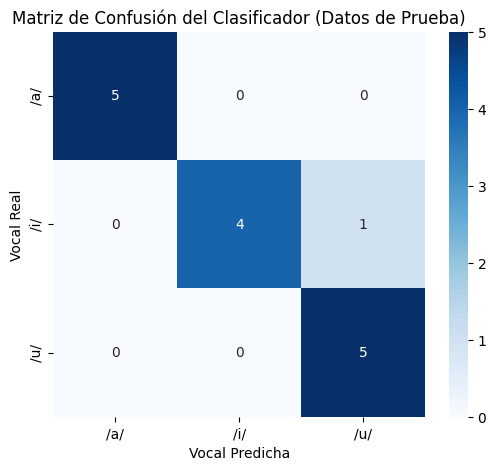


--- Resultados de la Clasificación Externa ---
Distancia a la plantilla /a/: 0.015360
Distancia a la plantilla /i/: 0.204872
Distancia a la plantilla /u/: 0.085842
Predicción Final: ¡La vocal pronunciada es la /a/!


'a'

In [ ]:
from google.colab import files
uploaded = files.upload()

# =====================================================================
# PASO 8: SISTEMA DE CLASIFICACIÓN Y EVALUACIÓN FINAL
# =====================================================================
# Clasificador por mínima distancia coseno.

y_reales = []
y_predichas = []

for el in datos_prueba:
    vector_sujeto = el['vector']

    # Calcular distancias a las tres plantillas
    dists = {vocal: distancia_coseno(vector_sujeto, plantillas_promedio[vocal]) for vocal in ['a', 'i', 'u']}

    # Predicción: vocal con la distancia coseno mínima
    vocal_predicha = min(dists, key=dists.get)

    y_reales.append(el['vocal'])
    y_predichas.append(vocal_predicha)

# Calcular Porcentaje de Aciertos (Accuracy)
y_reales = np.array(y_reales)
y_predichas = np.array(y_predichas)
porcentaje_aciertos = np.mean(y_reales == y_predichas) * 100

print("\n=====================================================================")
print(f"RESULTADO DE EVALUACIÓN FINAL: {porcentaje_aciertos:.2f}% de aciertos.")
print("=====================================================================")

# Construcción Manual de la Matriz de Confusión para explicación del procedimiento
clases = ['a', 'i', 'u']
matriz_confusion = np.zeros((3, 3), dtype=int)

for r, p in zip(y_reales, y_predichas):
    idx_real = clases.index(r)
    idx_pred = clases.index(p)
    matriz_confusion[idx_real, idx_pred] += 1

# Graficar Matriz de Confusión de forma estética
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusion, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"/{v}/" for v in clases],
            yticklabels=[f"/{v}/" for v in clases])
plt.title("Matriz de Confusión del Clasificador (Datos de Prueba)")
plt.xlabel("Vocal Predicha")
plt.ylabel("Vocal Real")
plt.show()


# =====================================================================
# NOTA 1: FUNCIÓN PARA INTRODUCIR EL AUDIO (CUALQUIER RUTA EXTERNA)
# =====================================================================

def clasificar_vocal_externa(ruta_audio_prueba):
    """
    Función que recibirá el profesor en la sustentación para manipular desde su PC.
    Recibe la ruta física de cualquier archivo WAV de 16 kHz y predice la vocal.
    """
    try:
        # 1. Extracción de características exacta utilizando la misma metodología del diseño
        vector_prueba = extraer_vector_energia(ruta_audio_prueba)

        # 2. Calcular distancias coseno respecto a las plantillas calculadas previamente
        distancias = {}
        for vocal in ['a', 'i', 'u']:
            distancias[vocal] = distancia_coseno(vector_prueba, plantillas_promedio[vocal])

        # 3. Decisión por mínima distancia
        vocal_ganadora = min(distancias, key=distancias.get)

        print("\n--- Resultados de la Clasificación Externa ---")
        for vocal in ['a', 'i', 'u']:
            print(f"Distancia a la plantilla /{vocal}/: {distancias[vocal]:.6f}")
        print(f"Predicción Final: ¡La vocal pronunciada es la /{vocal_ganadora}/!")

        return vocal_ganadora
    except Exception as e:
        print(f"Error al procesar el archivo: {e}")
        return None

# Ejemplo de llamada para la sustentación:
# clasificar_vocal_externa("ruta/de/la/grabacion/profesor.wav")
clasificar_vocal_externa("adrian.wav")